# DEM contour tutorial

Generate contour isobands from DEMs using `contourrs.contours_arrow`
and visualize them with GeoPandas + Matplotlib.

We start with a synthetic Gaussian-peak DEM, then apply the same
workflow to a real Mt. Rainier elevation model.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from contourrs import contours_arrow

## Synthetic DEM

Sum of three Gaussian peaks to simulate a mountain range.

In [2]:
size = 256
y, x = np.mgrid[-3 : 3 : complex(size), -3 : 3 : complex(size)]
dem = (
    np.exp(-(x**2 + y**2))
    + 0.7 * np.exp(-((x - 1.5) ** 2 + (y - 1) ** 2) / 0.5)
    + 0.5 * np.exp(-((x + 1.5) ** 2 + (y + 1.5) ** 2) / 0.8)
).astype(np.float32)

print(f"DEM shape: {dem.shape}, range: [{dem.min():.3f}, {dem.max():.3f}]")

DEM shape: (256, 256), range: [0.000, 1.003]


### Extract contour isobands

Define elevation thresholds and use `contours_arrow` to produce
filled contour polygons (isobands) as an Arrow table.
Convert to a GeoDataFrame for easy plotting.

In [3]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9, 1.1]

table = contours_arrow(dem, thresholds=thresholds)
gdf = gpd.GeoDataFrame.from_arrow(table)

print(f"Isobands: {len(gdf)} polygons")
print(f"Threshold values: {sorted(gdf['value'].unique())}")
gdf.head()

Isobands: 7 polygons
Threshold values: [np.float64(0.1), np.float64(0.3), np.float64(0.5), np.float64(0.7), np.float64(0.9)]


,geometry,value
0,"POLYGON ((57 15.99, 58 15.856, 59 15.744, 60 1...",0.1
1,"POLYGON ((59 36.928, 60 36.766, 61 36.641, 62 ...",0.3
2,"POLYGON ((64 58.948, 65 58.932, 65.488 59, 66 ...",0.5
3,"POLYGON ((114 91.994, 115 91.799, 116 91.628, ...",0.5
4,"POLYGON ((121 101.98, 122 101.813, 123 101.684...",0.7


### Plot: synthetic raster vs contour polygons

Side-by-side comparison of the continuous DEM and the filled contour bands.

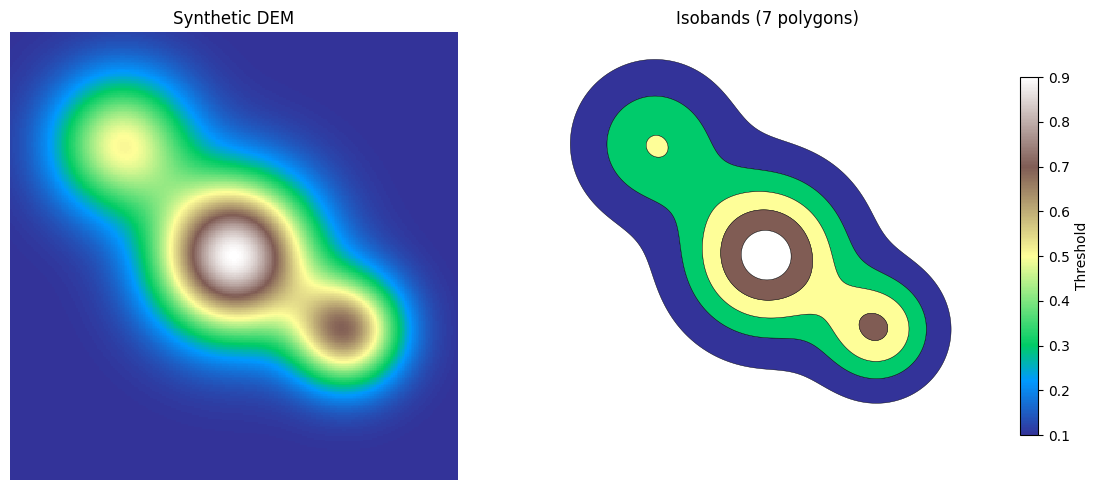

In [4]:
h, w = dem.shape

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: continuous DEM
axes[0].imshow(dem, cmap="terrain", interpolation="nearest", extent=(0, w, h, 0))
axes[0].set_title("Synthetic DEM")
axes[0].set_axis_off()
axes[0].set_xlim(0, w)
axes[0].set_ylim(h, 0)
axes[0].set_aspect("equal")

# Right: filled contour polygons
gdf.plot(
    ax=axes[1],
    column="value",
    cmap="terrain",
    edgecolor="black",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Threshold", "shrink": 0.8},
)
axes[1].set_title(f"Isobands ({len(gdf)} polygons)")
axes[1].set_axis_off()
axes[1].set_xlim(0, w)
axes[1].set_ylim(h, 0)
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

## Real DEM: Mt. Rainier

Apply the same contour workflow to a real 2048x2048 DEM of
Mt. Rainier (`examples/data/mt_rainier_dem_2048.tif`).

In [5]:
dem_path = Path("data/mt_rainier_dem_2048.tif")
if not dem_path.exists():
    dem_path = Path("examples/data/mt_rainier_dem_2048.tif")

with rasterio.open(dem_path) as src:
    real_dem = src.read(1)
    bounds = src.bounds
    nodata = src.nodata
    transform = src.transform

print(f"Shape: {real_dem.shape}, dtype: {real_dem.dtype}")
print(f"Elevation range: [{real_dem.min():.0f}, {real_dem.max():.0f}] m")
print(f"Bounds: {bounds}")

Shape: (2048, 2048), dtype: float32
Elevation range: [874, 4392] m
Bounds: BoundingBox(left=-121.8552777780595, bottom=46.758055555634236, right=-121.66564814822587, top=46.94768518546787)


### Extract contours from Mt. Rainier

Use elevation thresholds spaced every 250 m.

In [6]:
# Mask out nodata
mask = np.ones(real_dem.shape, dtype=bool)
if nodata is not None:
    mask &= real_dem != nodata

valid = real_dem[mask]
vmin = float(valid.min())
vmax = float(valid.max())

# Quantile-based thresholds for visually balanced elevation bins
n_bins = 8
real_thresholds = [float(np.quantile(valid, q)) for q in np.linspace(0, 1, n_bins + 1)]
print(
    f"Thresholds ({len(real_thresholds)}):"
    f" {real_thresholds[0]:.0f} .. {real_thresholds[-1]:.0f} m"
)

real_table = contours_arrow(
    real_dem, thresholds=real_thresholds, nodata=nodata, transform=transform,
)
gdf_real = gpd.GeoDataFrame.from_arrow(real_table)

print(f"Elevation bins: {len(gdf_real)} polygons")
gdf_real.head()

Thresholds (9): 874 .. 4392 m
Elevation bins: 205 polygons


,geometry,value
0,"POLYGON ((-121.85528 46.94778, -121.85537 46.9...",874.071167
1,"POLYGON ((-121.85528 46.94778, -121.85537 46.9...",1406.597092
2,"POLYGON ((-121.8062 46.93974, -121.80625 46.93...",1406.597092
3,"POLYGON ((-121.80935 46.78697, -121.80937 46.7...",1406.597092
4,"POLYGON ((-121.84463 46.77863, -121.84465 46.7...",1406.597092


### Plot: Mt. Rainier raster vs contour polygons

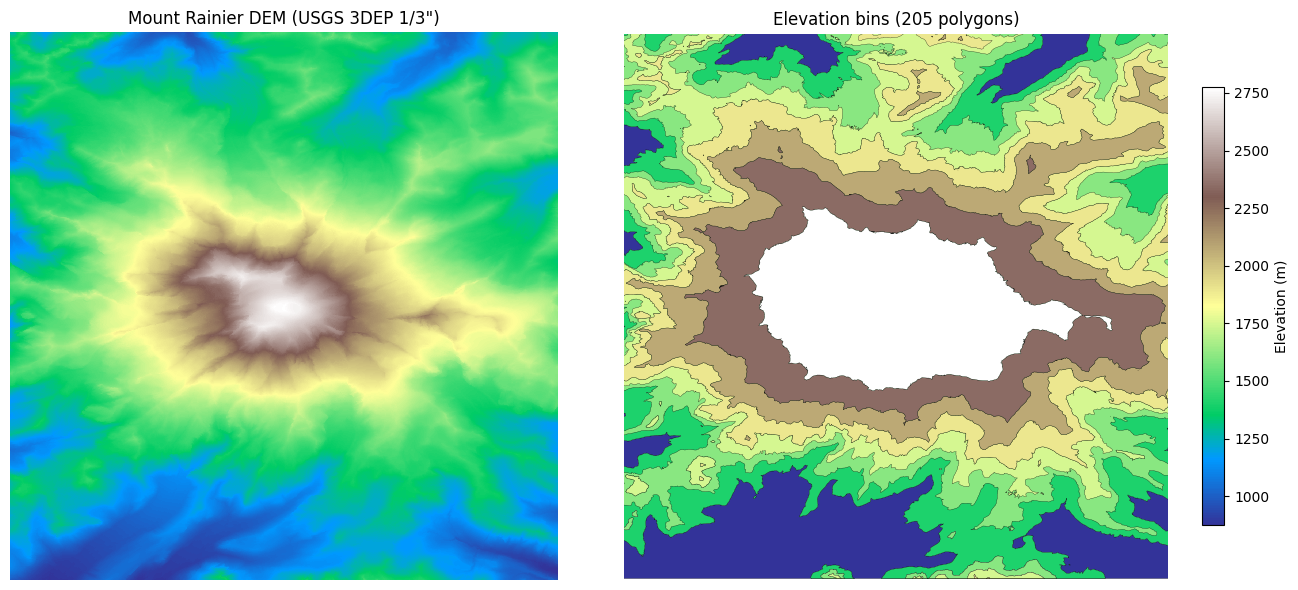

In [7]:
extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
h, w = real_dem.shape

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: real DEM raster
axes[0].imshow(real_dem, cmap="terrain", interpolation="nearest", extent=extent)
axes[0].set_title('Mount Rainier DEM (USGS 3DEP 1/3")')
axes[0].set_axis_off()
axes[0].set_xlim(bounds.left, bounds.right)
axes[0].set_ylim(bounds.bottom, bounds.top)
axes[0].set_aspect("equal")

# Right: contour isobands
gdf_real.plot(
    ax=axes[1],
    column="value",
    cmap="terrain",
    edgecolor="black",
    linewidth=0.2,
    legend=True,
    legend_kwds={"label": "Elevation (m)", "shrink": 0.8},
)
axes[1].set_title(f"Elevation bins ({len(gdf_real)} polygons)")
axes[1].set_axis_off()
axes[1].set_xlim(bounds.left, bounds.right)
axes[1].set_ylim(bounds.bottom, bounds.top)
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()